# AdaBoost

## The Big Idea: Weak Learners Voting Together

A **weak learner** is a model that does only slightly better than random guessing — not impressive on its own. The insight behind AdaBoost (short for **Adaptive Boosting**) is that you can combine a large number of weak learners into a single strong learner that performs very well.

Here's the intuition. Imagine you're grading a hard exam, and you ask a hundred people who each know just a little about the subject. If they all vote independently, their errors tend to cancel out and their correct answers reinforce each other. The catch is that the errors only cancel if the people are making *different* mistakes — you don't want a hundred people who all stumble on the same questions.

AdaBoost solves this by training each weak learner on a version of the data that **emphasizes the examples the previous learners got wrong**. Each new learner is steered toward the mistakes of the ones before it, so they complement each other rather than all failing in the same place.

The final prediction is a **weighted majority vote** across all the learners, where learners that performed better during training get more say.

## Weak Learners: Decision Stumps

AdaBoost can use any weak learner, but the canonical choice is a **decision stump** — a decision tree with a maximum depth of 1. A stump makes exactly one binary split: it picks one feature, picks one threshold, and puts everything below the threshold in one class and everything above it in the other.

A single stump is laughably simple. On a problem like classifying two interleaving moon shapes, one straight cut won't do much. But we're not going to use one stump. We're going to use many, each focused on the mistakes the earlier ones made.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_moons
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import ipywidgets as widgets
from IPython.display import display

## The Algorithm, Step by Step

Here is the full AdaBoost training loop in plain English:

1. **Initialize equal weights.** Every training example starts with the same weight: 1/N, where N is the number of examples. Weights represent how much attention the next stump should pay to each example.

2. **Train a stump on the weighted data.** Fit a depth-1 decision tree, using the current weights to emphasize certain examples.

3. **Compute weighted error.** Add up the weights of all the examples this stump got wrong. If the stump is no better than chance, this sum is 0.5.

4. **Compute the learner's weight (alpha).** A stump with low error gets a high alpha — it earns more influence in the final vote. The formula is:

   $$\alpha = \frac{1}{2} \ln\left(\frac{1 - \text{error}}{\text{error}}\right)$$

   An error of 0.5 (random chance) gives alpha = 0. An error near 0 gives a large positive alpha.

5. **Update sample weights.** Misclassified examples get their weights multiplied up (by $e^{\alpha}$); correctly classified examples get their weights multiplied down (by $e^{-\alpha}$). Then renormalize so the weights still sum to 1.

6. **Repeat** steps 2–5 for however many estimators you've specified.

7. **Final prediction** is the sign of the weighted sum of all stumps' predictions:

   $$H(x) = \text{sign}\left(\sum_{t=1}^{T} \alpha_t \cdot h_t(x)\right)$$

Let's implement this from scratch so the mechanics are concrete before we hand off to sklearn.

In [2]:
def adaboost_from_scratch(X, y, n_estimators=10):
    """Returns a list of (alpha, stump) pairs — our ensemble."""
    n = len(y)
    weights = np.ones(n) / n          # Step 1: equal weights
    ensemble = []

    # Convert labels to {-1, +1} — the math requires this sign convention
    y_signed = np.where(y == 0, -1, 1)

    for _ in range(n_estimators):
        stump = DecisionTreeClassifier(max_depth=1)
        stump.fit(X, y_signed, sample_weight=weights)   # Step 2

        predictions = stump.predict(X)
        wrong = predictions != y_signed

        error = np.dot(weights, wrong)                  # Step 3: weighted error
        error = np.clip(error, 1e-10, 1 - 1e-10)       # guard against log(0)

        alpha = 0.5 * np.log((1 - error) / error)      # Step 4: learner weight

        # Step 5: update sample weights
        weights *= np.exp(-alpha * y_signed * predictions)
        weights /= weights.sum()                        # renormalize

        ensemble.append((alpha, stump))

    return ensemble


def adaboost_predict(ensemble, X):
    weighted_votes = sum(
        alpha * stump.predict(X)
        for alpha, stump in ensemble
    )
    # Convert back from {-1, +1} to {0, 1}
    return np.where(weighted_votes >= 0, 1, 0)

## Quick Check on Make Moons

`make_moons` generates two interleaving half-circles — a dataset that is impossible to separate with a single straight cut but manageable for an ensemble. We'll verify our from-scratch implementation produces reasonable accuracy before moving to sklearn.

In [3]:
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

ensemble = adaboost_from_scratch(X_train, y_train, n_estimators=50)
preds = adaboost_predict(ensemble, X_test)
print(f"From-scratch AdaBoost accuracy (50 estimators): {accuracy_score(y_test, preds):.3f}")

From-scratch AdaBoost accuracy (50 estimators): 0.933


## Using sklearn's AdaBoostClassifier

Now that the algorithm makes sense, we switch to sklearn's battle-tested implementation. The interface follows the usual `fit` / `predict` pattern.

A few parameters worth knowing:

- **`n_estimators`** — how many weak learners to chain together. More is generally better up to a point; beyond that it levels off.
- **`estimator`** — the weak learner to use. We'll stick with the default depth-1 decision stump.
- **`learning_rate`** — shrinks each alpha before applying it. Lower learning rate needs more estimators but can produce a more regularized ensemble. We'll leave it at 1.0 (the default) for now.

In [4]:
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf = AdaBoostClassifier(n_estimators=50, random_state=42)
clf.fit(X_train, y_train)

print(f"sklearn AdaBoost accuracy (50 estimators): {accuracy_score(y_test, clf.predict(X_test)):.3f}")

sklearn AdaBoost accuracy (50 estimators): 0.878


/Users/chelseatroy/.pyenv/versions/3.10.8/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


## Visualizing the Decision Boundary

A single decision stump can only make one axis-aligned cut through the feature space. It looks like this — clearly not enough to capture the moons:

/Users/chelseatroy/.pyenv/versions/3.10.8/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/Users/chelseatroy/.pyenv/versions/3.10.8/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


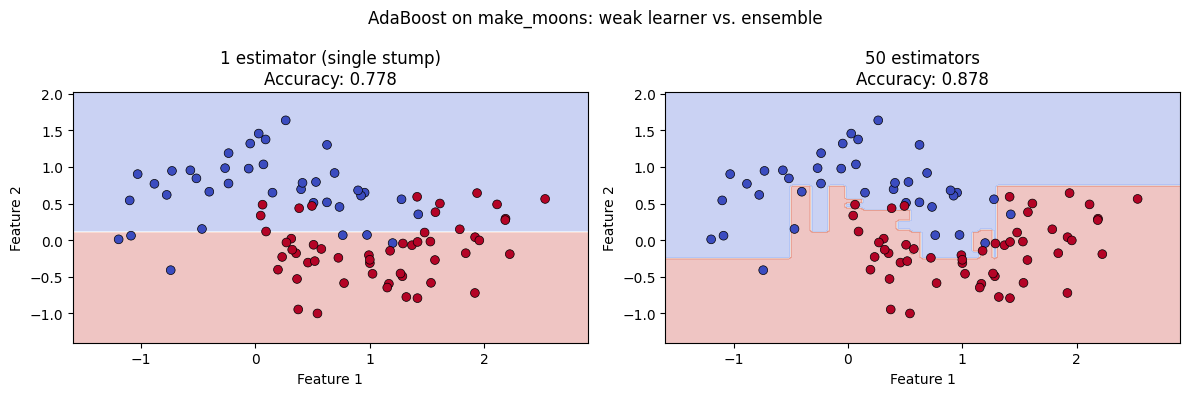

In [5]:
def plot_decision_boundary(ax, clf, X, y, title):
    """Draw filled decision regions and scatter the data points on ax."""
    h = 0.03
    x_min, x_max = X[:, 0].min() - 0.4, X[:, 0].max() + 0.4
    y_min, y_max = X[:, 1].min() - 0.4, X[:, 1].max() + 0.4
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm',
               edgecolors='k', linewidths=0.5, s=40)
    acc = accuracy_score(y, clf.predict(X))
    ax.set_title(f"{title}\nAccuracy: {acc:.3f}")
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

stump = AdaBoostClassifier(n_estimators=1, random_state=42)
stump.fit(X_train, y_train)
plot_decision_boundary(axes[0], stump, X_test, y_test, '1 estimator (single stump)')

strong = AdaBoostClassifier(n_estimators=50, random_state=42)
strong.fit(X_train, y_train)
plot_decision_boundary(axes[1], strong, X_test, y_test, '50 estimators')

plt.suptitle('AdaBoost on make_moons: weak learner vs. ensemble', fontsize=12)
plt.tight_layout()
plt.show()

## Interactive: Watch the Boundary Evolve

Use the slider below to increase the number of estimators from 1 to 100. Watch how the decision boundary starts as a single straight cut and gradually sculpts itself into a shape that traces the moons.

A few things to notice:

- **At 1–5 estimators**, the boundary is coarse and the accuracy is low.
- **Around 10–20 estimators**, it starts capturing the curved structure of the data.
- **Beyond ~30 estimators**, improvements are incremental and the boundary stabilizes.
- Unlike a deep single tree, AdaBoost's boundary rarely becomes jagged and over-fitted with more estimators — it tends to smooth out.

In [6]:
# Pre-fit a large ensemble once, then slice it to avoid re-training on every slider move
MAX_ESTIMATORS = 100
_full_clf = AdaBoostClassifier(n_estimators=MAX_ESTIMATORS, random_state=42)
_full_clf.fit(X_train, y_train)

def plot_for_n(n_estimators):
    # AdaBoostClassifier exposes staged_predict so we can evaluate any prefix;
    # for the boundary we build a lightweight wrapper that reuses the fitted estimators
    class SlicedAdaBoost:
        """Wraps the first n estimators of a fitted AdaBoostClassifier."""
        def __init__(self, base, n):
            self.estimators_ = base.estimators_[:n]
            self.estimator_weights_ = base.estimator_weights_[:n]
            self.classes_ = base.classes_

        def predict(self, X):
            # Weighted vote — mirrors AdaBoost's final decision rule
            vote = np.zeros((len(X), len(self.classes_)))
            for est, w in zip(self.estimators_, self.estimator_weights_):
                preds = est.predict(X)
                for i, cls in enumerate(self.classes_):
                    vote[:, i] += w * (preds == cls)
            return self.classes_[np.argmax(vote, axis=1)]

    sliced = SlicedAdaBoost(_full_clf, n_estimators)

    fig, ax = plt.subplots(figsize=(6, 5))
    plot_decision_boundary(ax, sliced, X_test, y_test,
                           f'AdaBoost — {n_estimators} estimator{"s" if n_estimators > 1 else ""}')
    plt.tight_layout()
    plt.show()

widgets.interact(
    plot_for_n,
    n_estimators=widgets.IntSlider(
        value=1, min=1, max=MAX_ESTIMATORS, step=1,
        description='Estimators',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='500px')
    )
)

/Users/chelseatroy/.pyenv/versions/3.10.8/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


interactive(children=(IntSlider(value=1, description='Estimators', layout=Layout(width='500px'), min=1, style=…

<function __main__.plot_for_n(n_estimators)>

## Strengths of AdaBoost

**It's simple and often works out of the box.** The only hyperparameter that usually matters is `n_estimators`, and the algorithm is not sensitive to its exact value — adding more estimators past a certain point just stops helping rather than hurting.

**Less prone to overfitting than a single deep tree.** A single tree with no depth limit will memorize the training data. AdaBoost builds many shallow trees and averages their votes, which smooths out individual mistakes. The ensemble's variance decreases as you add more estimators.

**No need to tune the weak learner.** Decision stumps have no hyperparameters to speak of. You can drop AdaBoost onto most tabular classification problems without a grid search and expect a reasonable result.

**Feature importance is interpretable.** Because the weak learners are decision stumps, you can inspect which features they split on most often (weighted by alpha) to get a sense of what's driving the ensemble's predictions.

## Weaknesses of AdaBoost

**Sensitive to noisy data and outliers.** This is the most important weakness to understand. At each round, AdaBoost increases the weights of the examples it got wrong. If an example is mislabeled or is a genuine outlier that no reasonable model would classify correctly, its weight will keep growing with each round. Eventually the ensemble dedicates enormous attention to chasing those outliers, and performance on the rest of the data suffers.

Compare this to a deep single tree, which might memorize the outlier in one leaf and then move on. AdaBoost's weight-boosting mechanism obsesses over it.

**Slower to train than bagging methods at the same number of estimators.** Because each stump depends on the results of the previous one (serial dependence), you can't parallelize the training loop the way you can with a Random Forest.

**Can still overfit if `n_estimators` is very large and the noise level is high.** The tendency toward overfitting is weaker than a single tree but not zero — especially when the data is dirty.

## Demonstrating Sensitivity to Outliers

Let's add a handful of deliberately mislabeled examples (outliers) to the training data and see how AdaBoost responds compared to a single decision tree.

In [7]:
rng = np.random.RandomState(0)

# Inject 10 outliers: points right in the center of each moon, labelled wrong
outlier_X = rng.uniform(-0.5, 2.0, size=(10, 2))
outlier_y = rng.randint(0, 2, size=10)

X_noisy = np.vstack([X_train, outlier_X])
y_noisy = np.concatenate([y_train, outlier_y])

ada_clean = AdaBoostClassifier(n_estimators=50, random_state=42).fit(X_train, y_train)
ada_noisy = AdaBoostClassifier(n_estimators=50, random_state=42).fit(X_noisy, y_noisy)
tree_noisy = DecisionTreeClassifier(max_depth=4, random_state=42).fit(X_noisy, y_noisy)

print(f"AdaBoost on clean data  — test accuracy: {accuracy_score(y_test, ada_clean.predict(X_test)):.3f}")
print(f"AdaBoost on noisy data  — test accuracy: {accuracy_score(y_test, ada_noisy.predict(X_test)):.3f}")
print(f"Decision tree (depth 4) on noisy data — test accuracy: {accuracy_score(y_test, tree_noisy.predict(X_test)):.3f}")

AdaBoost on clean data  — test accuracy: 0.878
AdaBoost on noisy data  — test accuracy: 0.878
Decision tree (depth 4) on noisy data — test accuracy: 0.900


/Users/chelseatroy/.pyenv/versions/3.10.8/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/Users/chelseatroy/.pyenv/versions/3.10.8/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


The drop in AdaBoost's accuracy from clean to noisy data illustrates the outlier sensitivity. The single tree with a moderate depth limit is less affected because it doesn't keep re-emphasizing the misclassified outliers — it just tucks them away in a leaf and moves on.

In practice, if your dataset has significant label noise or outliers, consider:
- Cleaning the data before boosting
- Using a Random Forest (which bags rather than boosts, making it more robust)
- Limiting `n_estimators` to prevent the ensemble from over-committing to the noise